# Caso 3 — Semanal | Ceros aislados suavizados

**Descripción del caso:** Los datos semanales ya vienen neteados por el script original. El caso 3 suaviza ceros aislados (una semana sin venta entre dos semanas con venta) interpolándolos — evita que el modelo aprenda falsos valles.

---

## 1. Instalación e imports

Corré esta celda primero para instalar las dependencias necesarias.

In [1]:
# Instalación (solo la primera vez)
# !pip install xgboost pandas openpyxl scikit-learn matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import xgboost as xgb
    USE_XGB = True
    print("✅ XGBoost cargado correctamente")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB = False
    print("⚠️  XGBoost no encontrado — usando GradientBoostingRegressor (instala con: pip install xgboost)")


✅ XGBoost cargado correctamente


## 2. Carga y limpieza de datos

**Criterio aplicado:** Ceros aislados interpolados con vecinos

Semanas cargadas: 269
Negativos encontrados: 0
Ceros encontrados: 57
Rango: 2021-01-04 → 2026-02-23

Serie final: 269 semanas
Demanda promedio semanal: 986


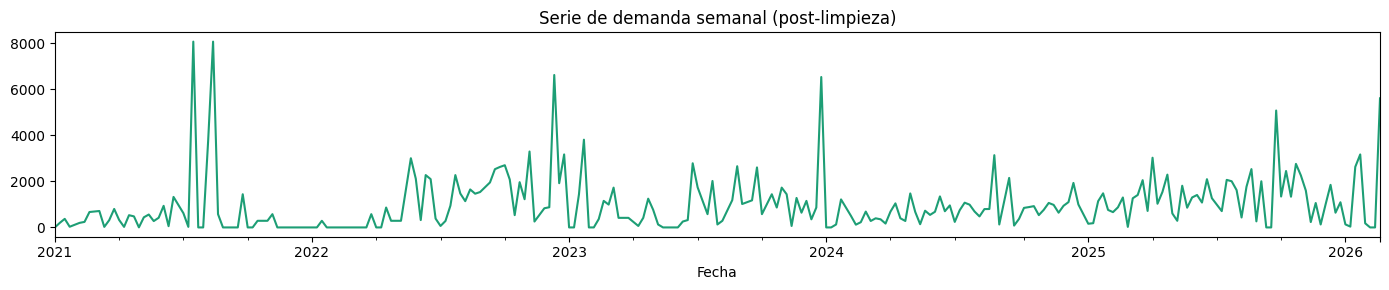

In [3]:
# ── Carga de datos ──────────────────────────────────────────
ARCHIVO = "Producto_281670015_semanal.csv"   # ajustá el path si es necesario

df = pd.read_csv(ARCHIVO)
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values("Fecha").reset_index(drop=True)

print(f"Semanas cargadas: {len(df)}")
print(f"Negativos encontrados: {(df['Demanda'] < 0).sum()}")
print(f"Ceros encontrados: {(df['Demanda'] == 0).sum()}")
print(f"Rango: {df['Fecha'].min().date()} → {df['Fecha'].max().date()}")

# ── Limpieza — Los datos semanales ya vienen neteados por el scri ──
# CASO 3: Suavizar ceros aislados (una semana sin venta entre dos con venta)
ts = df.set_index("Fecha")["Demanda"].clip(lower=0)
vals = ts.values.copy()
for i in range(1, len(vals) - 1):
    if vals[i] == 0 and vals[i-1] > 0 and vals[i+1] > 0:
        vals[i] = (vals[i-1] + vals[i+1]) / 2
ts = pd.Series(vals, index=ts.index)

print(f"\nSerie final: {len(ts)} semanas")
print(f"Demanda promedio semanal: {ts.mean():.0f}")
ts.plot(figsize=(14, 3), title="Serie de demanda semanal (post-limpieza)", color="#1D9E75")
plt.tight_layout(); plt.show()


## 3. Features para XGBoost

XGBoost no entiende fechas directamente. Necesitamos convertir la información temporal en columnas numéricas: lags, medias móviles, y variables de calendario.

In [4]:
def construir_features(ts):
    """
    Features para predicción semanal.
    Agrega features de semana del año para capturar estacionalidad
    semanal (ej: semana 1 = enero, típicamente baja).
    Los lags más largos (26, 52) capturan patrones de medio año y anual.
    """
    df = pd.DataFrame({"y": ts}).reset_index()
    df.columns = ["fecha", "y"]
    
    df["mes_num"]    = df["fecha"].dt.month
    df["semana_año"] = df["fecha"].dt.isocalendar().week.astype(int)
    df["trimestre"]  = df["fecha"].dt.quarter
    df["año"]        = df["fecha"].dt.year
    df["t"]          = range(len(df))
    
    for lag in [1, 2, 3, 4, 8, 13, 26, 52]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    
    for v in [4, 8, 13, 26]:
        df[f"roll_mean_{v}"] = df["y"].shift(1).rolling(v).mean()
        df[f"roll_std_{v}"]  = df["y"].shift(1).rolling(v).std()
        df[f"roll_max_{v}"]  = df["y"].shift(1).rolling(v).max()
    
    df["diff_1"] = df["y"].diff(1)
    
    return df.dropna().reset_index(drop=True)


## 4. Modelo XGBoost

Hiperparámetros usados y por qué:

In [5]:
def construir_modelo():
    """
    Hiperparámetros de XGBoost explicados:
      n_estimators  : cuántos árboles construye (más = más preciso pero más lento)
      learning_rate : qué tan grande es cada paso de aprendizaje (menor = más fino)
      max_depth     : profundidad de cada árbol (más = aprende patrones más complejos)
      subsample     : fracción de datos usada por árbol (evita overfitting)
      colsample_bytree: fracción de features usada por árbol
      min_child_weight: mínimo de muestras en una hoja (regularización)
    """
    if USE_XGB:
        return xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0
        )
    else:
        return GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=42
        )


## 5. Walk-Forward Cross-Validation

Esta es la forma correcta de evaluar modelos de series temporales.

Cada predicción usa **solo datos del pasado** — simulamos el modelo en producción real.

- Mínimo de historia: **52 semanas** antes de la primera predicción

In [6]:
def walk_forward_cv(ts, min_train=52):
    """
    Walk-Forward CV para datos semanales.
    min_train=52 → necesitamos al menos 1 año completo de historia
    para que el modelo vea un ciclo estacional completo antes de predecir.
    """
    df = construir_features(ts)
    feature_cols = [c for c in df.columns if c not in ["fecha", "y"]]
    X = df[feature_cols].values
    y = df["y"].values
    fechas = df["fecha"].values

    actuals, preds, dates = [], [], []

    for i in range(min_train, len(df)):
        model = construir_modelo()
        model.fit(X[:i], y[:i])
        pred = float(model.predict(X[i:i+1])[0])
        preds.append(max(0, pred))
        actuals.append(float(y[i]))
        dates.append(pd.Timestamp(fechas[i]))

    return np.array(actuals), np.array(preds), dates


## 6. Correr el modelo

In [7]:
min_train=52
print("Corriendo Walk-Forward CV...")
print(f"Serie: {len(ts)} semanas | Primeras predicciones a partir del período {min_train+1}")
print()

actuals, preds, dates = walk_forward_cv(ts, min_train=52)

print(f"✅ Predicciones generadas: {len(preds)} puntos")


Corriendo Walk-Forward CV...
Serie: 269 semanas | Primeras predicciones a partir del período 53

✅ Predicciones generadas: 165 puntos


## 7. Métricas de evaluación

Explicación de cada métrica:

In [8]:
def calcular_metricas(actuals, preds):
    """
    Métricas para evaluar predicción de demanda:
    
    MAE   → error absoluto medio en unidades. Fácil de interpretar.
            Ej: MAE=150 significa que en promedio nos equivocamos 150 unidades.
    
    RMSE  → similar al MAE pero penaliza más los errores grandes.
            Útil para detectar si hay meses con error muy alto.
    
    MAPE  → error en porcentaje. Ej: 20% = nos equivocamos 20% del valor real.
            ⚠️ Puede explotar si hay valores reales muy cercanos a 0.
    
    SMAPE → versión más robusta del MAPE. Usa el promedio de real+predicho
            en el denominador, evitando la inestabilidad del MAPE.
            Es la métrica principal a comparar entre casos.
    
    Bias  → sesgo sistemático del modelo.
            Bias > 0 → el modelo SOBREESTIMA (predice más de lo real)
            Bias < 0 → el modelo SUBESTIMA (predice menos de lo real)
            Bias ideal = 0
    
    R²    → qué % de la varianza explica el modelo.
            R²=1 → perfecto | R²=0 → igual que predecir el promedio | R²<0 → malo
    """
    mae  = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    
    mask = actuals > 0
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    
    smape = np.mean(2 * np.abs(actuals - preds) / (np.abs(actuals) + np.abs(preds) + 1e-9)) * 100
    
    bias = np.mean(preds - actuals)
    
    ss_res = np.sum((actuals - preds) ** 2)
    ss_tot = np.sum((actuals - actuals.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "Bias": bias, "R2": r2}

def imprimir_metricas(m):
    print("=" * 45)
    print(f"  MAE    : {m['MAE']:>8.1f}  unidades por período")
    print(f"  RMSE   : {m['RMSE']:>8.1f}  penaliza errores grandes")
    print(f"  MAPE   : {m['MAPE']:>7.2f}%")
    print(f"  SMAPE  : {m['SMAPE']:>7.2f}%  ← métrica principal")
    print(f"  Bias   : {m['Bias']:>+8.1f}  (+ sobreestima / - subestima)")
    print(f"  R²     : {m['R2']:>8.3f}")
    print("=" * 45)


In [9]:
metricas = calcular_metricas(actuals, preds)
imprimir_metricas(metricas)


  MAE    :    291.9  unidades por período
  RMSE   :    418.9  penaliza errores grandes
  MAPE   :   67.71%
  SMAPE  :   47.13%  ← métrica principal
  Bias   :     -4.3  (+ sobreestima / - subestima)
  R²     :    0.828


## 8. Visualización

In [10]:
def graficar(dates, actuals, preds, titulo):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Gráfico 1: real vs predicho
    axes[0].plot(dates, actuals, label="Real", color="#378ADD", linewidth=2)
    axes[0].plot(dates, preds, label="Predicho", color="#D85A30",
                 linewidth=2, linestyle="--")
    axes[0].fill_between(dates, actuals, preds, alpha=0.1, color="#D85A30")
    axes[0].set_title(titulo, fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Demanda")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)
    
    # Gráfico 2: error por período
    errores = np.array(preds) - np.array(actuals)
    colores = ["#D85A30" if e > 0 else "#378ADD" for e in errores]
    axes[1].bar(dates, errores, color=colores, alpha=0.7, width=20)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Error de predicción (Predicho − Real)", fontsize=11)
    axes[1].set_ylabel("Error (unidades)")
    axes[1].grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.show()


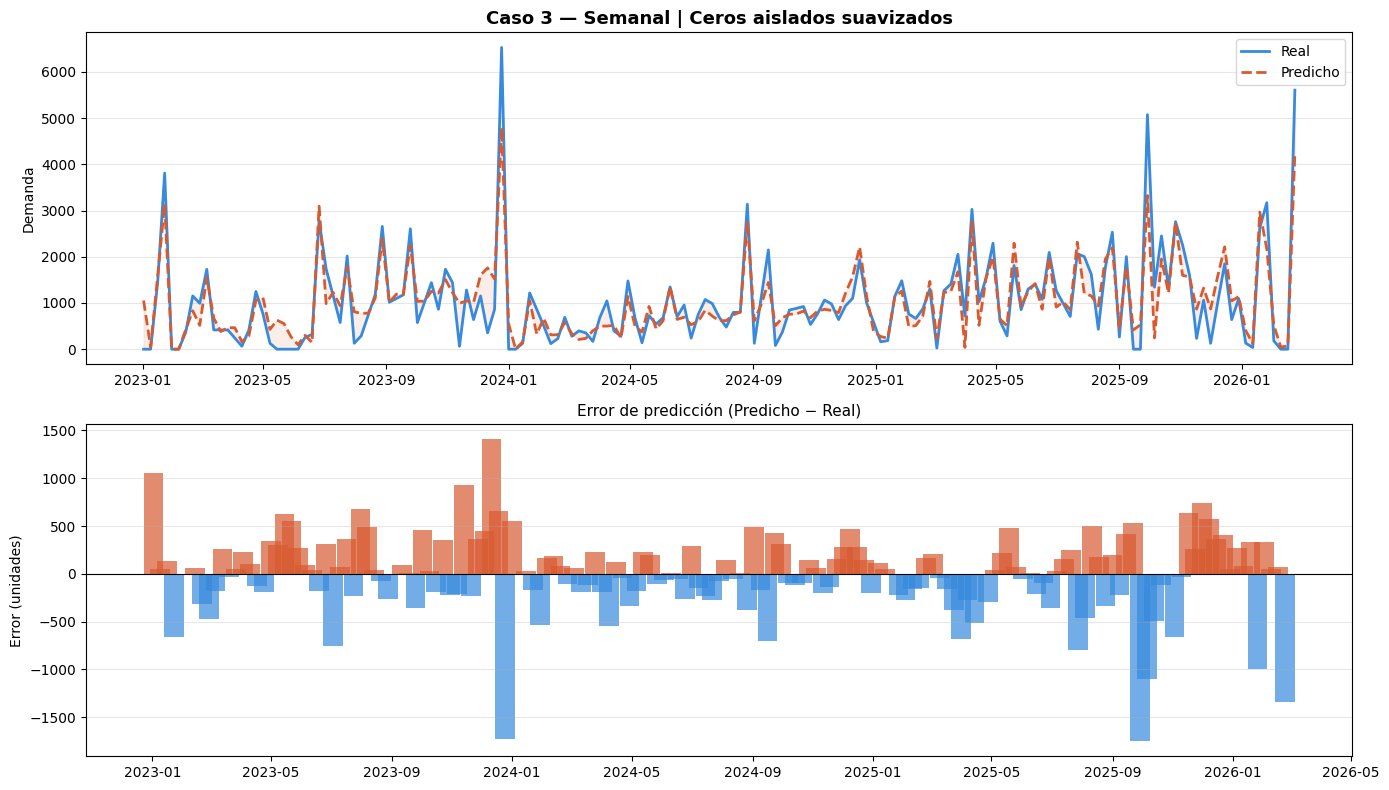

In [11]:
graficar(dates, actuals, preds, "Caso 3 — Semanal | Ceros aislados suavizados")

## 9. Resumen

Guardá estos resultados para comparar con los otros notebooks.

In [12]:
print("\n📋 RESUMEN PARA COMPARACIÓN")
print("=" * 45)
print(f"Notebook : Caso 3 — Semanal | Ceros aislados suavizados")
print(f"Períodos evaluados: {len(actuals)} semanas")
print(f"SMAPE  : {metricas['SMAPE']:.2f}%  ← métrica principal")
print(f"MAE    : {metricas['MAE']:.1f} unidades")
print(f"RMSE   : {metricas['RMSE']:.1f} unidades")
print(f"Bias   : {metricas['Bias']:+.1f} (+ sobreestima / - subestima)")
print(f"R²     : {metricas['R2']:.3f}")
print("=" * 45)
print("\n⬆️  Copiá estos valores al notebook de comparacion_final.ipynb")



📋 RESUMEN PARA COMPARACIÓN
Notebook : Caso 3 — Semanal | Ceros aislados suavizados
Períodos evaluados: 165 semanas
SMAPE  : 47.13%  ← métrica principal
MAE    : 291.9 unidades
RMSE   : 418.9 unidades
Bias   : -4.3 (+ sobreestima / - subestima)
R²     : 0.828

⬆️  Copiá estos valores al notebook de comparacion_final.ipynb
